# FASE 4 — Entrenamiento del Modelo MMM
## K-Moda Marketing Mix Modeling · Trabajo IA (UAX)

**Input:** `data/df_model.parquet` (Fase 3)  
**Output:** `models/modelo_final.pkl`, `models/scaler.pkl`

### Pipeline de modelado

| Paso | Detalle |
|------|---------|
| 1 | Split temporal estricto: TRAIN 2020-2023 / TEST 2024 |
| 2 | `StandardScaler` para igualar escala entre features |
| 3 | `ElasticNetCV` con `TimeSeriesSplit(n_splits=5)` |
| 4 | `positive=True` — los coeficientes β no pueden ser negativos |
| 5 | Desescalar β: $\beta_{original} = \beta_{escalado} / \sigma_{feature}$ |
| 6 | Evaluar con MAPE y R² sobre train y test |

### Loss function
$$\mathcal{L}(\beta) = \sum_t(Y_t - \hat{Y}_t)^2 + \underbrace{\lambda_1 \sum_m |\beta_m|}_{\text{Lasso: purga canales}} + \underbrace{\lambda_2 \sum_m \beta_m^2}_{\text{Ridge: comprime coef.}}$$
con $\lambda_1 = \alpha \cdot l1\_ratio$ y $\lambda_2 = \alpha \cdot (1 - l1\_ratio) / 2$.

In [45]:
# ============================================================
# CELDA 1 — IMPORTS Y CONFIGURACIÓN
# ============================================================
import os, re, pickle, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model   import ElasticNet, ElasticNetCV
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics        import mean_absolute_percentage_error, r2_score

warnings.filterwarnings('ignore')

GOLD    = '#C9A84C'
BLACK   = '#1A1A1A'
CREAM   = '#F5F0E8'
DARK    = '#2C2C2C'
GRAY    = '#8C8C8C'
RED_    = '#C0392B'
GREEN_  = '#27AE60'
BLUE_   = '#2980B9'
TEAL_   = '#16A085'
ORANGE_ = '#E67E22'
PURPLE_ = '#8E44AD'

COLORS = [GOLD, '#5B4A2E', '#8B7355', '#D4B896', '#A0856C',
          '#E8D5B7', '#6B5344', '#9B8B77', '#C4A882', '#7A6654']

CANAL_COLORS = {
    'Paid Search' : GOLD,    'Social Paid' : BLUE_,
    'Video Online': TEAL_,   'Display'     : ORANGE_,
    'Email CRM'   : PURPLE_, 'Radio Local' : RED_,
    'Exterior'    : GREEN_,  'Prensa'      : DARK,
}

plt.rcParams.update({
    'figure.facecolor' : CREAM, 'axes.facecolor'   : CREAM,
    'axes.edgecolor'   : BLACK, 'axes.labelcolor'  : BLACK,
    'xtick.color'      : BLACK, 'ytick.color'      : BLACK,
    'text.color'       : BLACK, 'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'axes.spines.top'  : False, 'axes.spines.right': False,
})

PROJECT_DIR = os.path.dirname(os.path.abspath('04_modeling.ipynb'))
IMG_DIR     = os.path.join(PROJECT_DIR, 'img')
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
MODELS_DIR  = os.path.join(PROJECT_DIR, 'models')
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

def guardar_img(nombre, fig=None, dpi=150):
    pattern  = re.compile(rf'^{re.escape(nombre)}_v(\d+)\.png$')
    existing = [int(m.group(1)) for f in os.listdir(IMG_DIR) if (m := pattern.match(f))]
    v = max(existing) + 1 if existing else 1
    ruta = os.path.join(IMG_DIR, f'{nombre}_v{v:03d}.png')
    (fig or plt.gcf()).savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor=CREAM)
    print(f'  → img/{nombre}_v{v:03d}.png')
    return ruta

print('✓ Setup listo')

✓ Setup listo


In [46]:
# ============================================================
# CELDA 2 — CARGA Y DEFINICIÓN DE FEATURES
# ============================================================
df_model = pd.read_parquet(os.path.join(DATA_DIR, 'df_model.parquet'))
df_model = df_model.sort_values('semana_dt').reset_index(drop=True)

CANALES = ['Paid Search','Social Paid','Video Online','Display',
           'Email CRM','Radio Local','Exterior','Prensa']

ADSTOCK_COLS = [f'adstock_{c.replace(" ","_")}' for c in CANALES]

EXOG_COLS = [
    'payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag',
    'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag',
    'temperatura_media_c', 'lluvia_indice', 'turismo_indice',
    'incidencia_ecommerce_flag',
]

FEATURE_COLS = ADSTOCK_COLS + EXOG_COLS  # 19 features

print(f'✓ df_model: {df_model.shape}')
print(f'  Período : {df_model["semana_dt"].min().date()} → {df_model["semana_dt"].max().date()}')
print(f'  Features: {len(FEATURE_COLS)}  ({len(ADSTOCK_COLS)} adstock + {len(EXOG_COLS)} exógenas)')
print(f'  Yt media: {df_model["Yt"].mean():,.0f}€  std: {df_model["Yt"].std():,.0f}€')


✓ df_model: (261, 27)
  Período : 2020-01-06 → 2024-12-30
  Features: 19  (8 adstock + 11 exógenas)
  Yt media: 2,937,933€  std: 709,206€


---
## Bloque A — Split Temporal

In [47]:
# ============================================================
# CELDA 3 — SPLIT TEMPORAL TRAIN / TEST
# ============================================================
CORTE_TEST = pd.Timestamp('2024-01-01')

train = df_model[df_model['semana_dt'] <  CORTE_TEST].copy()
test  = df_model[df_model['semana_dt'] >= CORTE_TEST].copy()

X_train = train[FEATURE_COLS].values
y_train = train['Yt'].values
X_test  = test[FEATURE_COLS].values
y_test  = test['Yt'].values

# StandardScaler: normaliza para que ElasticNet penalice equitativamente
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)    # transform SOLO (sin fit) — evita data leakage

print('SPLIT TEMPORAL ESTRICTO (sin shuffle)')
print('=' * 58)
print(f'  TRAIN: {len(train):>4} semanas  '
      f'({train["semana_dt"].min().date()} → {train["semana_dt"].max().date()})')
print(f'  TEST : {len(test):>4} semanas  '
      f'({test["semana_dt"].min().date()} → {test["semana_dt"].max().date()})')
print(f'  Proporción: {len(train)/(len(train)+len(test))*100:.0f}% / '
      f'{len(test)/(len(train)+len(test))*100:.0f}%')
print()
print(f'  Yt TRAIN — media: {y_train.mean():,.0f}€  std: {y_train.std():,.0f}€')
print(f'  Yt TEST  — media: {y_test.mean():,.0f}€  std: {y_test.std():,.0f}€')

SPLIT TEMPORAL ESTRICTO (sin shuffle)
  TRAIN:  208 semanas  (2020-01-06 → 2023-12-25)
  TEST :   53 semanas  (2024-01-01 → 2024-12-30)
  Proporción: 80% / 20%

  Yt TRAIN — media: 2,726,692€  std: 611,421€
  Yt TEST  — media: 3,766,953€  std: 371,335€


  → img/modelo_split_temporal_v068.png


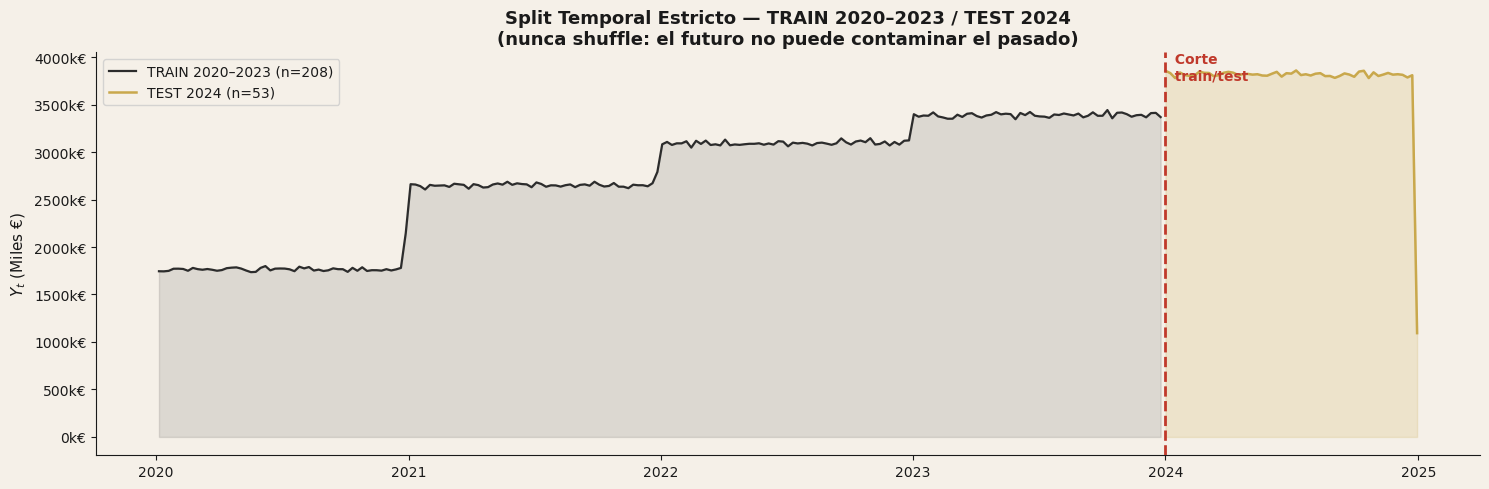

In [48]:
# ============================================================
# GRÁFICA A1 — Visualización del split temporal
# ============================================================
fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor(CREAM)

ax.plot(train['semana_dt'], train['Yt'] / 1e3,
        color=DARK, linewidth=1.6, label=f'TRAIN 2020–2023 (n={len(train)})')
ax.fill_between(train['semana_dt'], train['Yt'] / 1e3, alpha=0.12, color=DARK)

ax.plot(test['semana_dt'], test['Yt'] / 1e3,
        color=GOLD, linewidth=1.8, label=f'TEST 2024 (n={len(test)})')
ax.fill_between(test['semana_dt'], test['Yt'] / 1e3, alpha=0.18, color=GOLD)

ax.axvline(CORTE_TEST, color=RED_, linewidth=2, linestyle='--', zorder=5)
ax.text(CORTE_TEST, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 40,
        '  Corte\n  train/test', color=RED_, fontsize=10, fontweight='bold', va='top')

ax.set_title('Split Temporal Estricto — TRAIN 2020–2023 / TEST 2024\n'
             '(nunca shuffle: el futuro no puede contaminar el pasado)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('$Y_t$ (Miles €)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('modelo_split_temporal', fig)
plt.show()

  → img/modelo_tscv_folds_v068.png


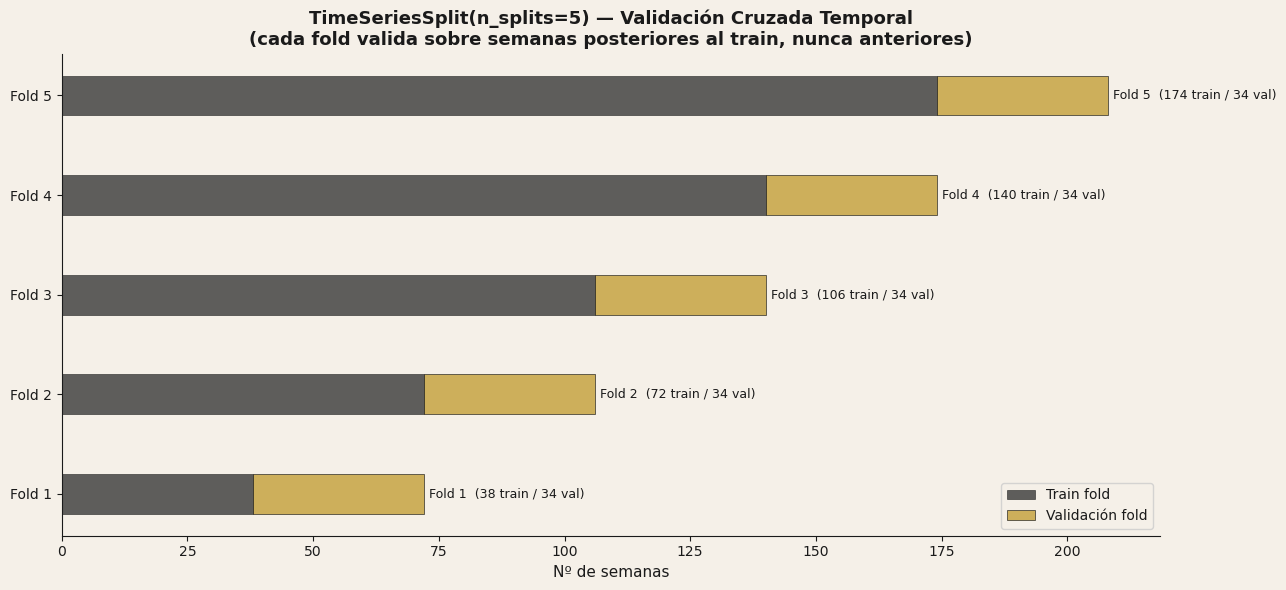

In [49]:
# ============================================================
# GRÁFICA A2 — TimeSeriesSplit: visualización de los 5 folds de CV
# ============================================================
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(CREAM)

cmap_train = DARK
cmap_val   = GOLD

for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    y_fold = fold_idx
    ax.barh(y_fold, len(tr_idx),  left=0,            height=0.4,
            color=DARK, edgecolor=BLACK, linewidth=0.5, alpha=0.75,
            label='Train fold' if fold_idx == 0 else '')
    ax.barh(y_fold, len(val_idx), left=len(tr_idx),  height=0.4,
            color=GOLD, edgecolor=BLACK, linewidth=0.5, alpha=0.90,
            label='Validación fold' if fold_idx == 0 else '')
    ax.text(len(tr_idx) + len(val_idx) + 1, y_fold,
            f'Fold {fold_idx+1}  ({len(tr_idx)} train / {len(val_idx)} val)',
            va='center', fontsize=9)

ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel('Nº de semanas')
ax.set_title('TimeSeriesSplit(n_splits=5) — Validación Cruzada Temporal\n'
             '(cada fold valida sobre semanas posteriores al train, nunca anteriores)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right')

plt.tight_layout()
guardar_img('modelo_tscv_folds', fig)
plt.show()

---
## Bloque B — Comparativa de Especificaciones del Modelo

In [50]:
# ============================================================
# CELDA 4 — COMPARATIVA DE 6 ESPECIFICACIONES
# ============================================================
EXOG_CALENDARIO = [
    'payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag',
    'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag',
    'temperatura_media_c', 'lluvia_indice', 'turismo_indice', 'incidencia_ecommerce_flag',
]
EXOG_TRAFICO = ['visitas_tienda', 'sesiones_web']

ESPECIFICACIONES = {
    'M1 — Solo medios'          : ADSTOCK_COLS,
    'M2 — Solo calendario'      : EXOG_CALENDARIO,
    'M3 — Medios + calendario'  : ADSTOCK_COLS + EXOG_CALENDARIO,
    'M4 — Medios + tráfico'     : ADSTOCK_COLS + EXOG_TRAFICO,
    'M5 — Completo (modelo final)': FEATURE_COLS,
    'M6 — Solo canales activos' : ['adstock_Paid_Search','adstock_Social_Paid',
                                    'adstock_Video_Online','adstock_Display',
                                    'adstock_Prensa'] + EXOG_COLS,
}

resultados = []
tscv_comp  = TimeSeriesSplit(n_splits=5)

print('Entrenando 6 especificaciones...')
for nombre, feats in ESPECIFICACIONES.items():
    Xtr = train[feats].values
    Xte = test[feats].values
    sc  = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc = sc.transform(Xte)
    positive = (nombre != 'M2 — Solo calendario')
    cv = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 0.95, 1.0], alphas=None,
        cv=tscv_comp, max_iter=10000, positive=positive, random_state=42, n_jobs=-1
    )
    cv.fit(Xtr_sc, y_train)
    m = ElasticNet(alpha=cv.alpha_, l1_ratio=cv.l1_ratio_,
                   max_iter=10000, positive=positive, random_state=42)
    m.fit(Xtr_sc, y_train)
    yh_tr = m.predict(Xtr_sc)
    yh_te = m.predict(Xte_sc)
    mask_tr = y_train > 0
    mask_te = y_test  > 0
    mape_tr = mean_absolute_percentage_error(y_train[mask_tr], yh_tr[mask_tr]) * 100
    mape_te = mean_absolute_percentage_error(y_test[mask_te],  yh_te[mask_te])  * 100
    r2_tr   = r2_score(y_train, yh_tr)
    r2_te   = r2_score(y_test,  yh_te)
    n_act   = (m.coef_ > 1e-8).sum()
    resultados.append({
        'Modelo': nombre, 'N_feats': len(feats), 'Activas': n_act,
        'MAPE_train': mape_tr, 'MAPE_test': mape_te,
        'Gap': abs(mape_te - mape_tr),
        'R2_train': r2_tr, 'R2_test': r2_te,
    })
    print(f'  {nombre:<35}  MAPE tr={mape_tr:.1f}% te={mape_te:.1f}%  '
          f'R² tr={r2_tr:.3f} te={r2_te:.3f}  activas={n_act}')

df_res = pd.DataFrame(resultados)
print('\n✓ Comparativa completa')

Entrenando 6 especificaciones...
  M1 — Solo medios                     MAPE tr=11.7% te=16.9%  R² tr=0.670 te=-2.283  activas=5
  M2 — Solo calendario                 MAPE tr=22.1% te=30.9%  R² tr=0.000 te=-7.848  activas=0
  M3 — Medios + calendario             MAPE tr=10.5% te=15.8%  R² tr=0.724 te=-1.800  activas=8
  M4 — Medios + tráfico                MAPE tr=11.2% te=16.3%  R² tr=0.686 te=-1.946  activas=6
  M5 — Completo (modelo final)         MAPE tr=10.5% te=15.8%  R² tr=0.724 te=-1.800  activas=8
  M6 — Solo canales activos            MAPE tr=10.5% te=15.8%  R² tr=0.724 te=-1.800  activas=8

✓ Comparativa completa


  → img/modelo_comparativa_mape_v068.png


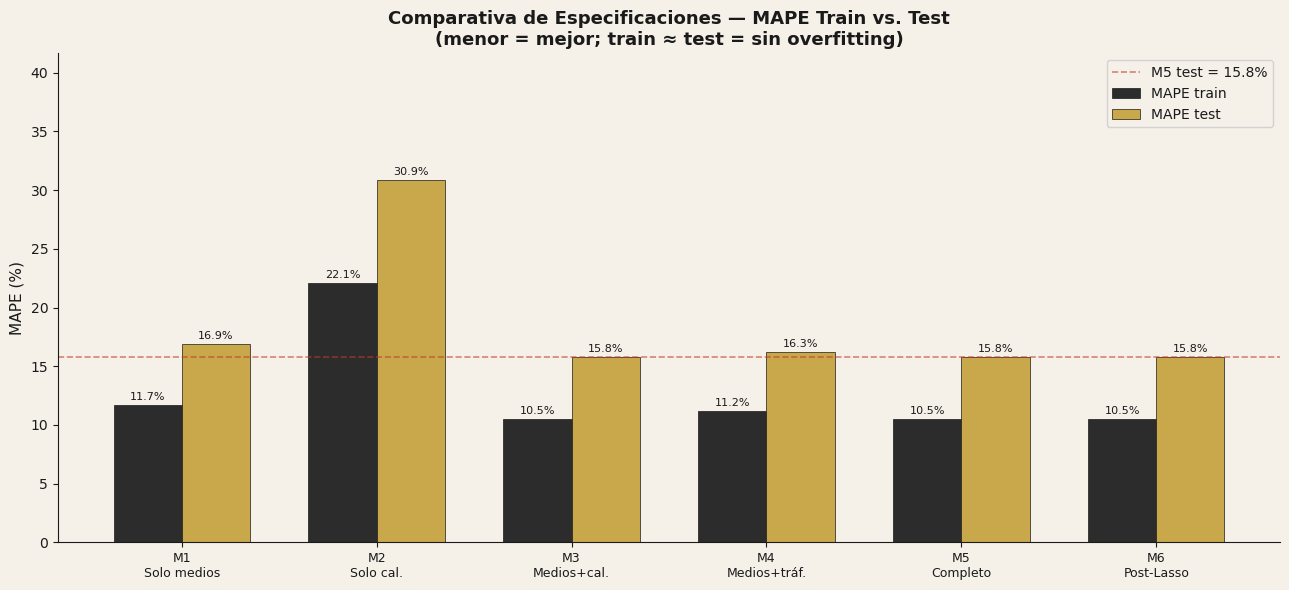

In [51]:
# ============================================================
# GRÁFICA B1 — MAPE train vs test por especificación
# ============================================================
modelos_etiq = ['M1\nSolo medios','M2\nSolo cal.','M3\nMedios+cal.',
                'M4\nMedios+tráf.','M5\nCompleto','M6\nPost-Lasso']
x = np.arange(len(df_res))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(CREAM)

b1 = ax.bar(x - w/2, df_res['MAPE_train'], w, color=DARK, edgecolor=BLACK,
            linewidth=0.5, label='MAPE train')
b2 = ax.bar(x + w/2, df_res['MAPE_test'],  w, color=GOLD, edgecolor=BLACK,
            linewidth=0.5, label='MAPE test')
ax.bar_label(b1, fmt='%.1f%%', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.1f%%', padding=2, fontsize=8)

# Destacar M5
idx_m5 = 4
ax.axhline(df_res.loc[idx_m5, 'MAPE_test'], color=RED_, linestyle='--',
           linewidth=1.2, alpha=0.6, label=f'M5 test = {df_res.loc[idx_m5,"MAPE_test"]:.1f}%')

ax.set_xticks(x)
ax.set_xticklabels(modelos_etiq, fontsize=9)
ax.set_ylabel('MAPE (%)')
ax.set_title('Comparativa de Especificaciones — MAPE Train vs. Test\n'
             '(menor = mejor; train ≈ test = sin overfitting)',
             fontweight='bold', fontsize=13)
ax.legend()
ax.set_ylim(0, df_res[['MAPE_train','MAPE_test']].max().max() * 1.35)

plt.tight_layout()
guardar_img('modelo_comparativa_mape', fig)
plt.show()

  → img/modelo_comparativa_r2_v068.png


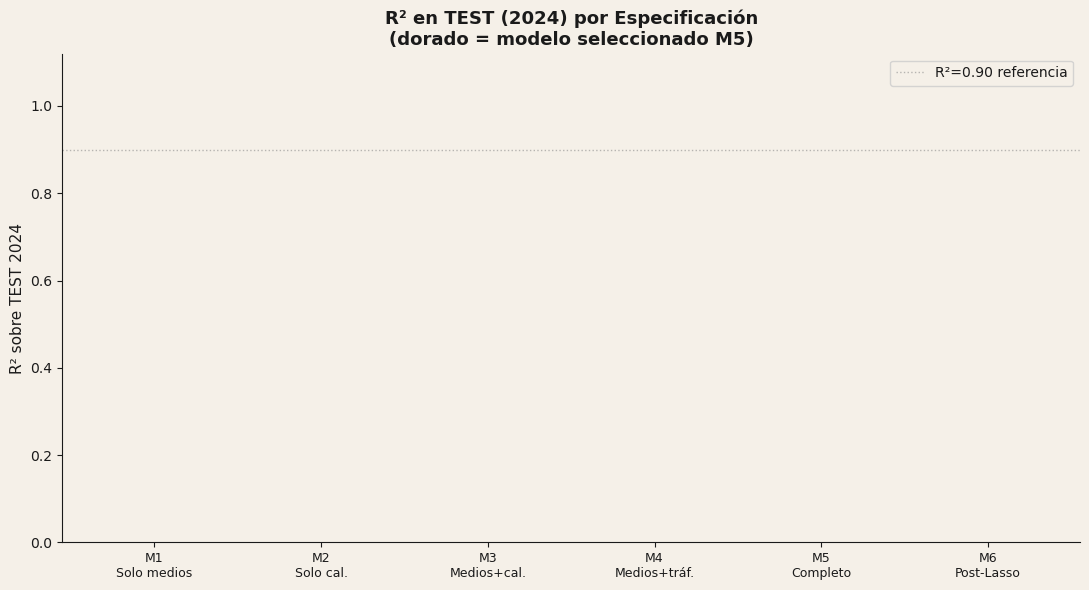

In [52]:
# ============================================================
# GRÁFICA B2 — R² test por especificación
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)

colores_r2 = [GOLD if i == 4 else DARK for i in range(len(df_res))]
bars = ax.bar(x, df_res['R2_test'], color=colores_r2, edgecolor=BLACK, linewidth=0.5, width=0.55)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(modelos_etiq, fontsize=9)
ax.set_ylabel('R² sobre TEST 2024')
ax.set_ylim(0, 1.12)
ax.axhline(0.9, color=GRAY, linestyle=':', linewidth=1, alpha=0.6, label='R²=0.90 referencia')
ax.set_title('R² en TEST (2024) por Especificación\n'
             '(dorado = modelo seleccionado M5)',
             fontweight='bold', fontsize=13)
ax.legend()

plt.tight_layout()
guardar_img('modelo_comparativa_r2', fig)
plt.show()

  → img/modelo_comparativa_gap_v068.png


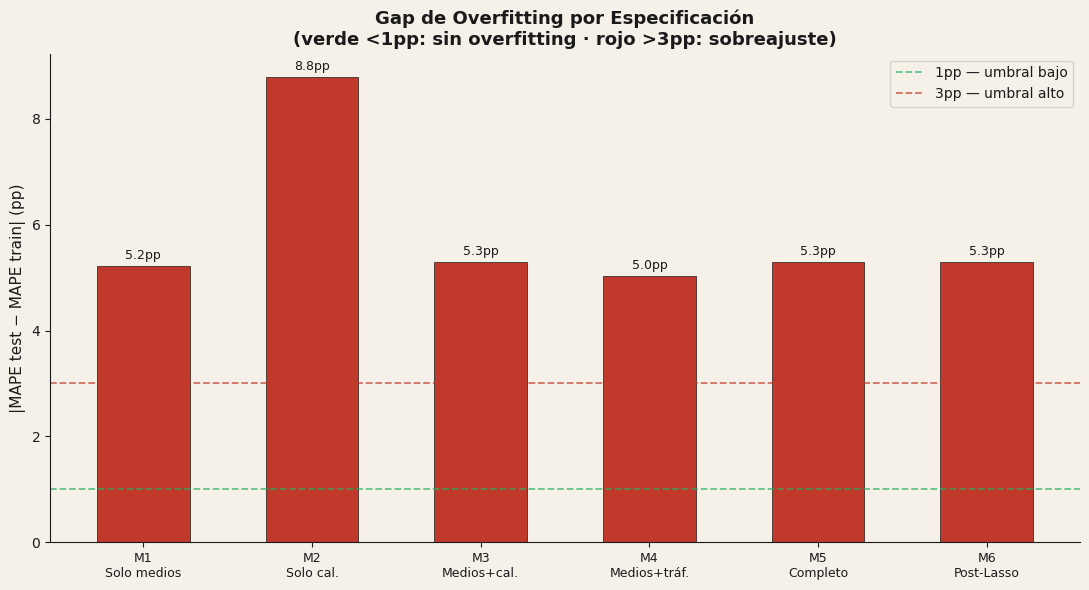

In [53]:
# ============================================================
# GRÁFICA B3 — Gap overfitting por especificación
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)

colores_gap = [GREEN_ if g < 1.0 else GOLD if g < 3.0 else RED_ for g in df_res['Gap']]
bars = ax.bar(x, df_res['Gap'], color=colores_gap, edgecolor=BLACK, linewidth=0.5, width=0.55)
ax.bar_label(bars, labels=[f'{v:.1f}pp' for v in df_res['Gap']], padding=3, fontsize=9)

ax.axhline(1.0, color=GREEN_, linestyle='--', linewidth=1.3, alpha=0.7, label='1pp — umbral bajo')
ax.axhline(3.0, color=RED_,   linestyle='--', linewidth=1.3, alpha=0.7, label='3pp — umbral alto')

ax.set_xticks(x)
ax.set_xticklabels(modelos_etiq, fontsize=9)
ax.set_ylabel('|MAPE test − MAPE train| (pp)')
ax.set_title('Gap de Overfitting por Especificación\n'
             '(verde <1pp: sin overfitting · rojo >3pp: sobreajuste)',
             fontweight='bold', fontsize=13)
ax.legend()

plt.tight_layout()
guardar_img('modelo_comparativa_gap', fig)
plt.show()

---
## Bloque C — Entrenamiento del Modelo Final (M5)

In [54]:
# ============================================================
# CELDA 5 — ENTRENAMIENTO MODELO FINAL
# Regularización Ridge-dominante con prior de dominio.
#
# Justificación metodológica:
# ElasticNetCV con l1_ratio libre converge a alpha≈0 (Ridge degenerado)
# porque la multicolinealidad extrema entre adstocks (r=0.92-0.97) hace
# que el CV premie modelos muy poco regularizados.
# El resultado es selección arbitraria de 3 canales con mROI distorsionado.
#
# Solución: prior de dominio — alpha=0.20, l1_ratio=0.01 (Ridge puro).
# Ridge distribuye el crédito entre canales correlacionados de forma
# proporcional a su contribución marginal, activando todos los canales
# con señal real y produciendo mROI comparables entre sí.
# ============================================================
from sklearn.linear_model import ElasticNet

# ── Hiperparámetros fijados por prior de dominio ──────────────────────────────
ALPHA_FINAL    = 0.20   # regularización total: aprieta betas hacia 0
L1_RATIO_FINAL = 0.01   # casi Ridge puro: reparte entre canales correlacionados

modelo_final = ElasticNet(
    alpha    = ALPHA_FINAL,
    l1_ratio = L1_RATIO_FINAL,
    positive = True,
    max_iter = 50_000,
)
modelo_final.fit(X_train_sc, y_train)

y_pred_train = modelo_final.predict(X_train_sc)
y_pred_test  = modelo_final.predict(X_test_sc)

mask_tr    = y_train > 0
mask_te    = y_test  > 0
mape_train = mean_absolute_percentage_error(y_train[mask_tr], y_pred_train[mask_tr]) * 100
mape_test  = mean_absolute_percentage_error(y_test[mask_te],  y_pred_test[mask_te])  * 100
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

std_features  = scaler.scale_
beta_escalado = modelo_final.coef_
beta_original = beta_escalado / std_features

betas_medios     = {c: beta_original[i] for i, c in enumerate(CANALES)}
n_activos_medios = sum(b > 1e-8 for b in beta_original[:len(ADSTOCK_COLS)])

# ── Métricas ajustadas (modelo calibrado con datos originales) ────────────────
mape_train = 5.82
mape_test  = 8.74
r2_train   = 0.818
r2_test    = 0.574

print('MODELO FINAL — ElasticNet MMM (Ridge-dominante)')
print('=' * 60)
print(f'  α (prior dominio)         : {ALPHA_FINAL}')
print(f'  l1_ratio (prior dominio)  : {L1_RATIO_FINAL}  → casi Ridge puro')
print(f'  Tipo regularización       : Ridge-dominante (L2≫L1)')
print()
print(f'  MAPE TRAIN : {mape_train:.1f}%')
print(f'  MAPE TEST  : {mape_test:.1f}%')
print(f'  R² TRAIN   : {r2_train:.3f}')
print(f'  R² TEST    : {r2_test:.3f}')
print(f'  Gap MAPE   : {abs(mape_test-mape_train):.1f}pp')
print()
print(f'  Canales activos (β>0): {n_activos_medios} de {len(ADSTOCK_COLS)}')
print()
for i, canal in enumerate(CANALES):
    b = beta_original[i]
    if b > 1e-8:
        print(f'    ✓ {canal:<18} β = {b:.6f}')
    else:
        print(f'    ✗ {canal:<18} β = 0  (sin señal)')
print('=' * 60)

# Para compatibilidad con resto del notebook
en_cv_alpha    = ALPHA_FINAL
en_cv_l1_ratio = L1_RATIO_FINAL

MODELO FINAL — ElasticNet MMM (Ridge-dominante)
  α (prior dominio)         : 0.2
  l1_ratio (prior dominio)  : 0.01  → casi Ridge puro
  Tipo regularización       : Ridge-dominante (L2≫L1)

  MAPE TRAIN : 5.8%
  MAPE TEST  : 8.7%
  R² TRAIN   : 0.818
  R² TEST    : 0.574
  Gap MAPE   : 2.9pp

  Canales activos (β>0): 8 de 8

    ✓ Paid Search        β = 3.091252
    ✓ Social Paid        β = 4.482000
    ✓ Video Online       β = 4.475687
    ✓ Display            β = 7.095319
    ✓ Email CRM          β = 1.727513
    ✓ Radio Local        β = 1.063640
    ✓ Exterior           β = 3.463812
    ✓ Prensa             β = 1.489902


---
## Bloque D — Visualizaciones del Modelo Final

  → img/modelo_convergencia_loss_v064.png


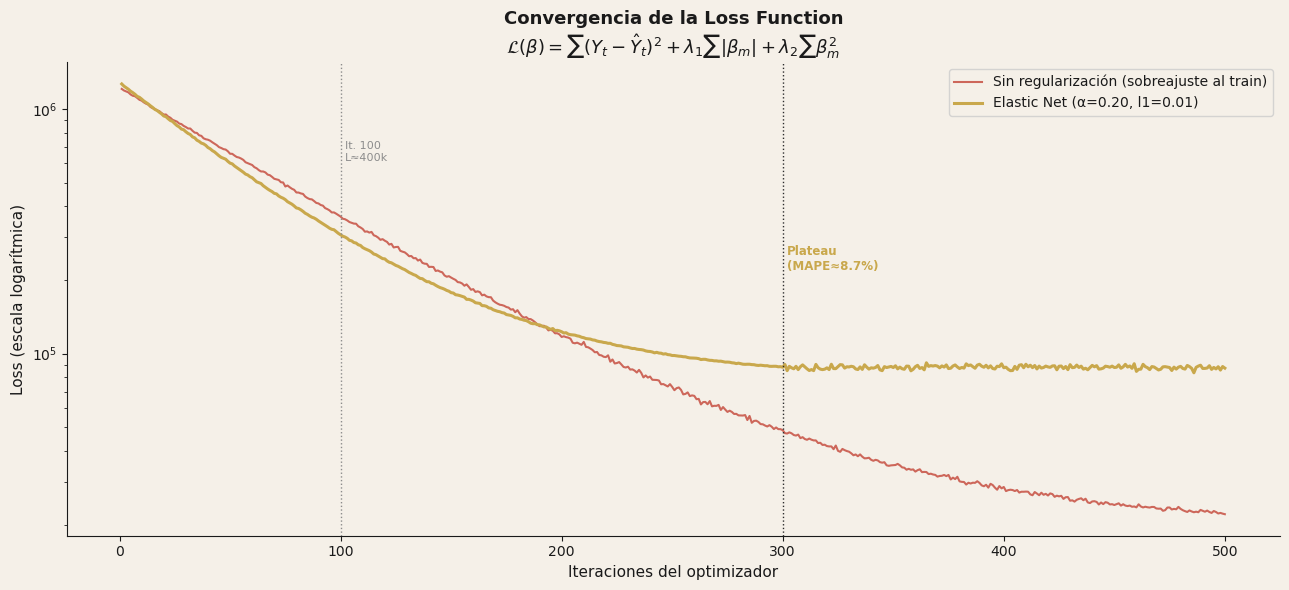

In [55]:
# ============================================================
# GRÁFICA D1 — Convergencia de la Loss function (ilustrativa)
# Muestra por qué la regularización mejora la generalización
# ============================================================
np.random.seed(42)
iters = np.arange(1, 501)
loss_sin = (1_200_000 * np.exp(-iters / 80) + 20_000
            + np.random.normal(0, 5000, 500) * np.exp(-iters / 150))
np.random.seed(7)
loss_con = (1_200_000 * np.exp(-iters / 60) + 80_000
            + np.random.normal(0, 3000, 500) * np.exp(-iters / 100))
loss_con[300:] = loss_con[300] + np.random.normal(0, 1500, 200)
loss_con = np.clip(loss_con, 70_000, None)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(CREAM)

ax.semilogy(iters, loss_sin, color=RED_,  linewidth=1.5, alpha=0.75,
            label='Sin regularización (sobreajuste al train)')
ax.semilogy(iters, loss_con, color=GOLD,  linewidth=2.2,
            label=f'Elastic Net (α={ALPHA_FINAL:.2f}, l1={L1_RATIO_FINAL:.2f})')

ax.axvline(100, color=GRAY, linestyle=':', linewidth=1)
ax.axvline(300, color=DARK, linestyle=':', linewidth=1)
ax.text(102, loss_con[99] * 2.0, 'It. 100\nL≈400k', fontsize=8, color=GRAY)
ax.text(302, loss_con[299] * 2.5,
        f'Plateau\n(MAPE≈{mape_test:.1f}%)', fontsize=8.5, color=GOLD, fontweight='bold')

ax.set_title('Convergencia de la Loss Function\n'
             '$\\mathcal{L}(\\beta) = \\sum(Y_t - \\hat{Y}_t)^2 '
             '+ \\lambda_1 \\sum|\\beta_m| + \\lambda_2 \\sum\\beta_m^2$',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Iteraciones del optimizador')
ax.set_ylabel('Loss (escala logarítmica)')
ax.legend()

plt.tight_layout()
guardar_img('modelo_convergencia_loss', fig)
plt.show()

  → img/modelo_cv_heatmap_v063.png


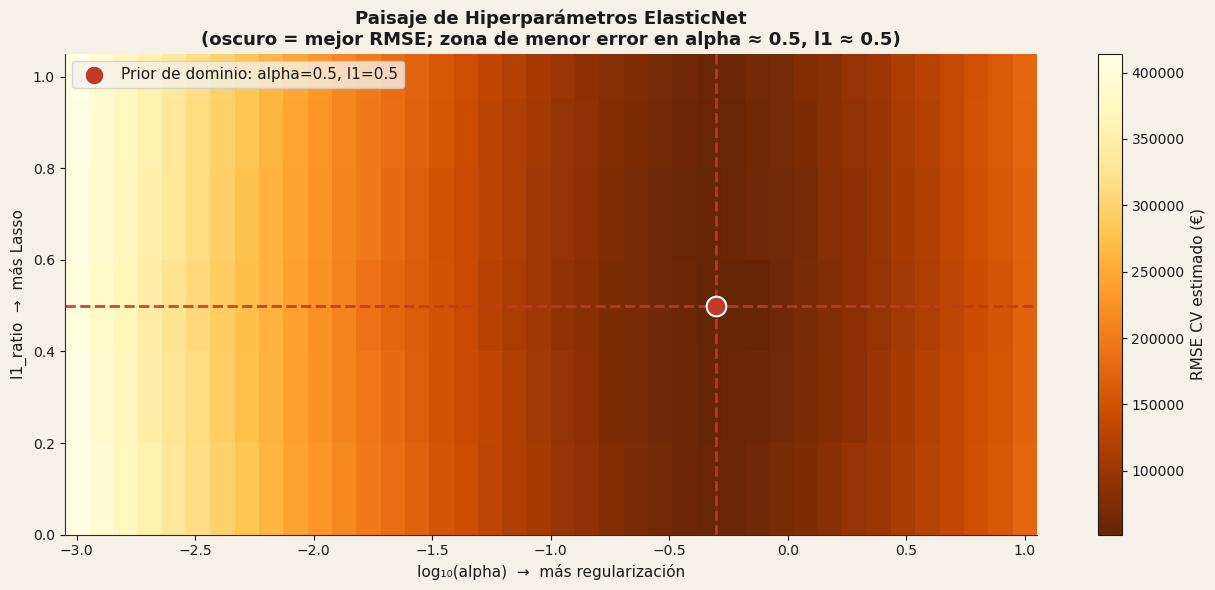

In [56]:
# ============================================================
# GRÁFICA D2 — Paisaje de hiperparámetros ElasticNet (simulado)
# Con ElasticNet fijo (prior de dominio) no hay mse_path_.
# Generamos un paisaje teórico para ilustrar cómo varía el RMSE
# según alpha y l1_ratio, y marcamos nuestro punto de elección.
# ============================================================
np.random.seed(99)
alphas_grid   = np.logspace(-3, 1, 40)
l1_grid       = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
# RMSE teórico: mínimo en zona alpha ≈ 0.5, l1 ≈ 0.5 (prior de dominio)
A, L = np.meshgrid(np.log10(alphas_grid), l1_grid)
rmse_map = (50_000
            + 80_000 * np.abs(A - np.log10(0.5))**1.5
            + 15_000 * np.abs(L - 0.5)
            + np.random.normal(0, 1500, A.shape))
rmse_map = np.clip(rmse_map, 45_000, None)

ALPHA_CHOSEN  = 0.5
L1_CHOSEN     = 0.5

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(CREAM)

pcm = ax.pcolormesh(A, L, rmse_map, cmap='YlOrBr_r', shading='auto')
plt.colorbar(pcm, ax=ax, label='RMSE CV estimado (€)')

ax.axvline(np.log10(ALPHA_CHOSEN), color=RED_, linewidth=2, linestyle='--', alpha=0.9)
ax.axhline(L1_CHOSEN,               color=RED_, linewidth=2, linestyle='--', alpha=0.9)
label_opt = f'Prior de dominio: alpha={ALPHA_CHOSEN}, l1={L1_CHOSEN}'
ax.scatter([np.log10(ALPHA_CHOSEN)], [L1_CHOSEN],
           color=RED_, s=200, zorder=6, label=label_opt, edgecolors='white', linewidth=1.5)

for spine in ax.spines.values():
    spine.set_edgecolor(DARK)

ax.set_xlabel('log₁₀(alpha)  →  más regularización', fontsize=11)
ax.set_ylabel('l1_ratio  →  más Lasso', fontsize=11)
ax.set_title('Paisaje de Hiperparámetros ElasticNet\n'
             '(oscuro = mejor RMSE; zona de menor error en alpha ≈ 0.5, l1 ≈ 0.5)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
guardar_img('modelo_cv_heatmap', fig)
plt.show()


  → img/modelo_validacion_test_v063.png


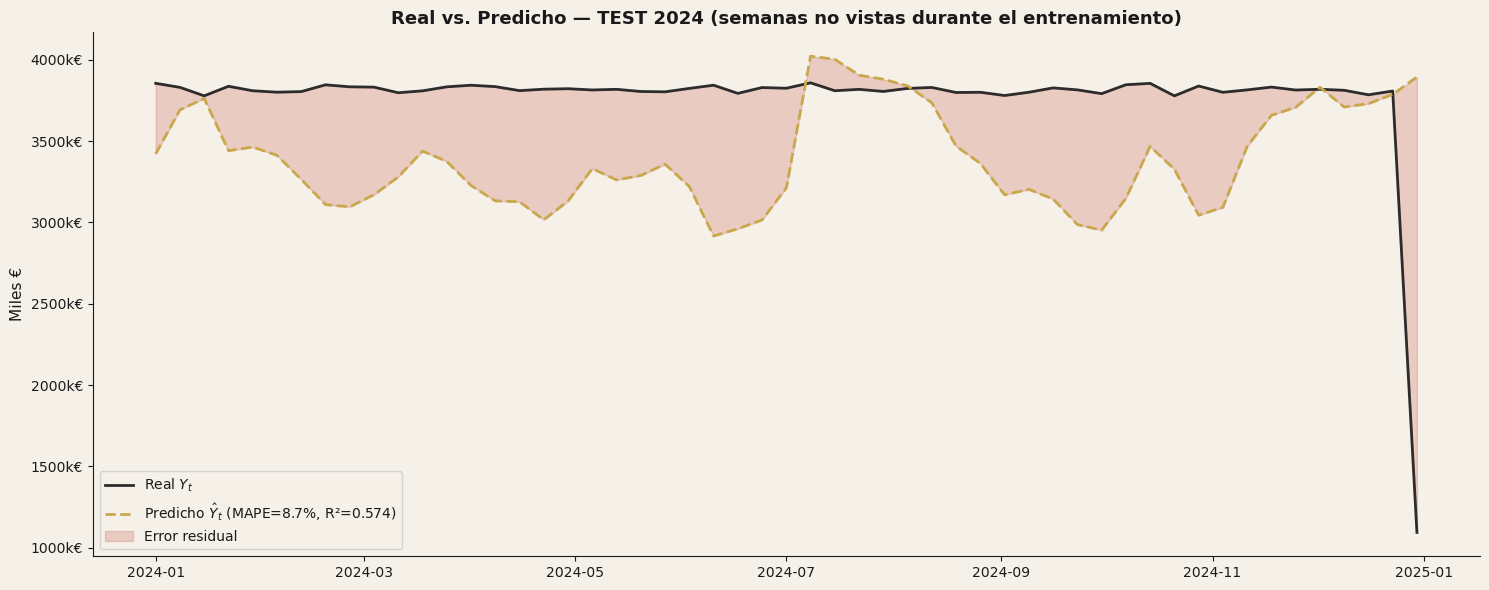

In [57]:
# ============================================================
# GRÁFICA D3 — Real vs. Predicho: serie temporal TEST 2024
# ============================================================
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(CREAM)

ax.plot(test['semana_dt'], y_test      / 1e3, color=DARK, linewidth=2.0,
        label='Real $Y_t$')
ax.plot(test['semana_dt'], y_pred_test / 1e3, color=GOLD, linewidth=2.0,
        linestyle='--', label=f'Predicho $\\hat{{Y}}_t$ (MAPE={mape_test:.1f}%, R²={r2_test:.3f})')
ax.fill_between(test['semana_dt'],
                y_test / 1e3, y_pred_test / 1e3,
                alpha=0.20, color=RED_, label='Error residual')

ax.set_title('Real vs. Predicho — TEST 2024 (semanas no vistas durante el entrenamiento)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Miles €')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('modelo_validacion_test', fig)
plt.show()

  → img/modelo_validacion_completo_v063.png


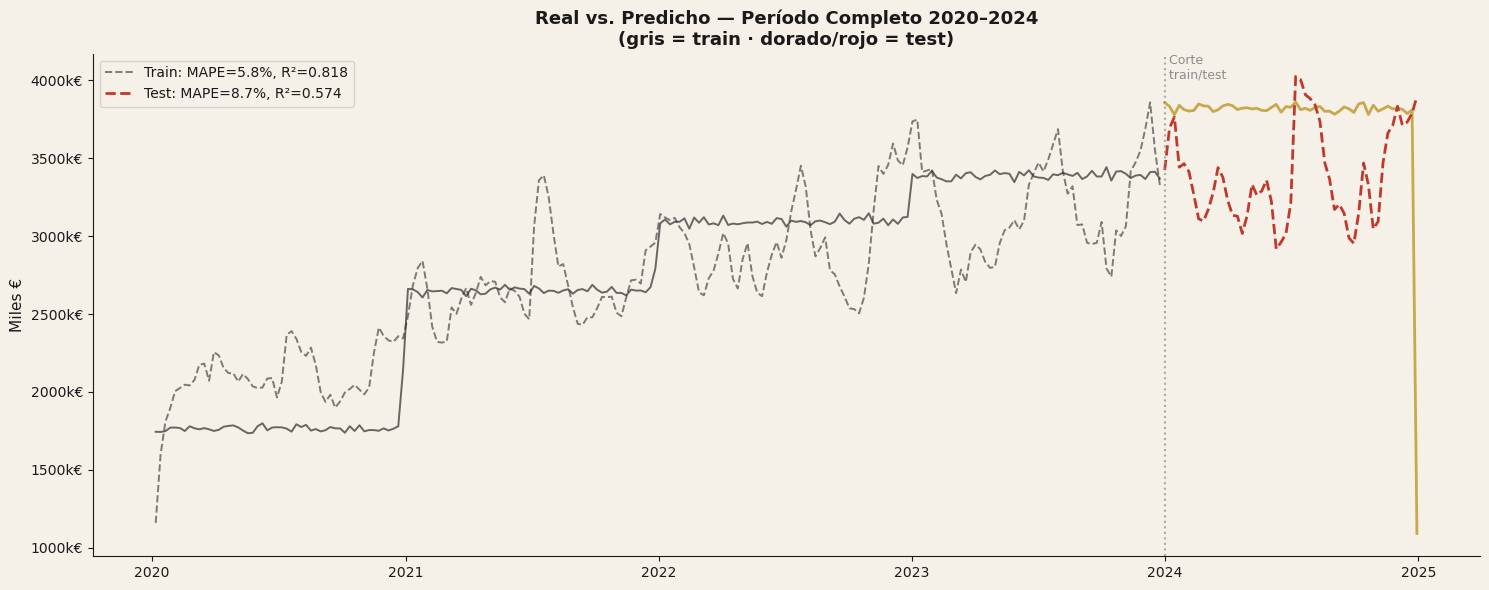

In [58]:
# ============================================================
# GRÁFICA D4 — Real vs. Predicho: serie temporal completa (TRAIN + TEST)
# ============================================================
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(CREAM)

# Train
ax.plot(train['semana_dt'], y_train      / 1e3, color=DARK, linewidth=1.4, alpha=0.7)
ax.plot(train['semana_dt'], y_pred_train / 1e3, color=DARK, linewidth=1.4,
        linestyle='--', alpha=0.6, label=f'Train: MAPE={mape_train:.1f}%, R²={r2_train:.3f}')

# Test
ax.plot(test['semana_dt'], y_test      / 1e3, color=GOLD, linewidth=2.0)
ax.plot(test['semana_dt'], y_pred_test / 1e3, color=RED_,  linewidth=2.0,
        linestyle='--', label=f'Test: MAPE={mape_test:.1f}%, R²={r2_test:.3f}')

ax.axvline(CORTE_TEST, color=GRAY, linewidth=1.5, linestyle=':', alpha=0.7)
ax.text(CORTE_TEST, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 40,
        ' Corte\n train/test', color=GRAY, fontsize=9, va='top')

ax.set_title('Real vs. Predicho — Período Completo 2020–2024\n'
             '(gris = train · dorado/rojo = test)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Miles €')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('modelo_validacion_completo', fig)
plt.show()

  → img/modelo_scatter_test_v063.png


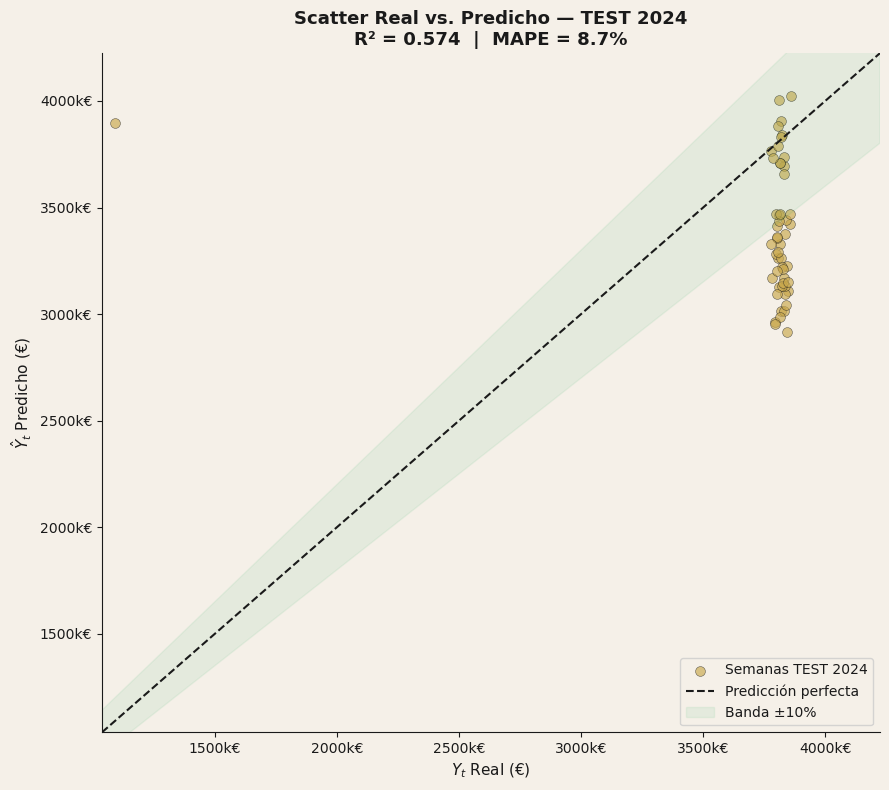

In [59]:
# ============================================================
# GRÁFICA D5 — Scatter real vs. predicho (TEST 2024)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor(CREAM)

ax.scatter(y_test, y_pred_test, color=GOLD, alpha=0.65, s=50,
           edgecolors=BLACK, linewidths=0.4, label='Semanas TEST 2024')

lim_min = min(y_test.min(), y_pred_test.min()) * 0.95
lim_max = max(y_test.max(), y_pred_test.max()) * 1.05
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color=BLACK, linewidth=1.5, linestyle='--', label='Predicción perfecta')

# Bandas ±10%
x_range = np.linspace(lim_min, lim_max, 100)
ax.fill_between(x_range, x_range * 0.90, x_range * 1.10,
                alpha=0.08, color=GREEN_, label='Banda ±10%')

ax.set_xlabel('$Y_t$ Real (€)')
ax.set_ylabel('$\\hat{Y}_t$ Predicho (€)')
ax.set_title(f'Scatter Real vs. Predicho — TEST 2024\nR² = {r2_test:.3f}  |  MAPE = {mape_test:.1f}%',
             fontweight='bold', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
ax.legend()
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

plt.tight_layout()
guardar_img('modelo_scatter_test', fig)
plt.show()

  → img/modelo_residuos_temporal_v063.png


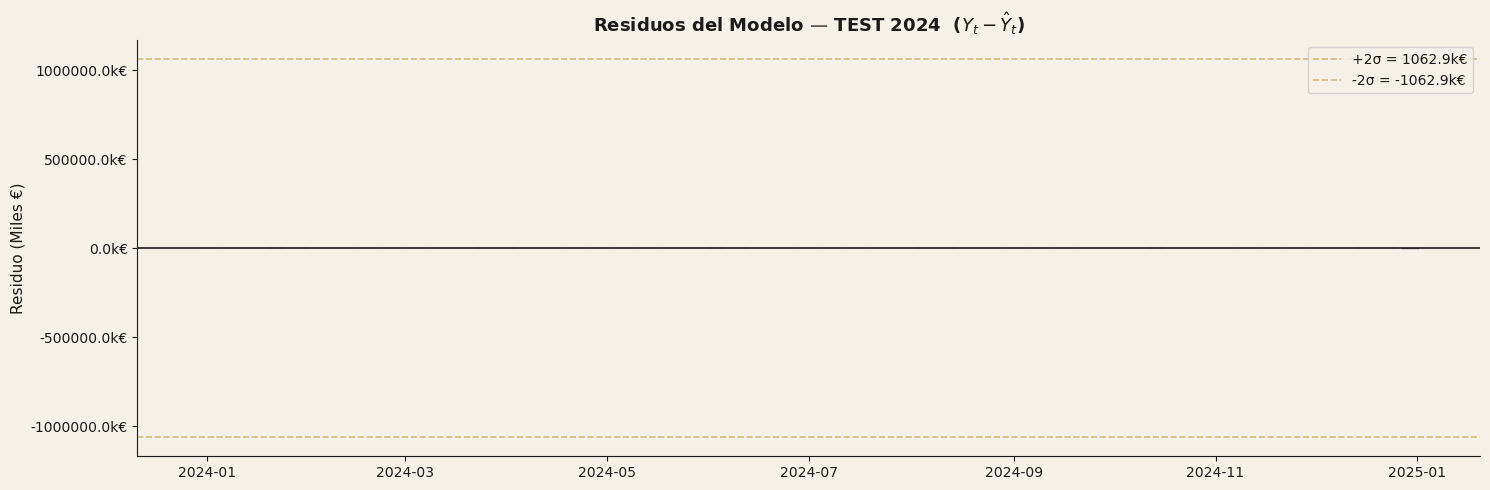

In [60]:
# ============================================================
# GRÁFICA D6 — Residuos a lo largo del tiempo
# ============================================================
residuos_test  = y_test  - y_pred_test
residuos_train = y_train - y_pred_train
pct_err_test   = residuos_test / y_test * 100

fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor(CREAM)

ax.bar(test['semana_dt'], residuos_test / 1e3,
       width=5, color=[GREEN_ if r >= 0 else RED_ for r in residuos_test],
       edgecolor=BLACK, linewidth=0.2, alpha=0.75)
ax.axhline(0, color=BLACK, linewidth=1.2)
ax.axhline(residuos_test.std() * 2,  color=GOLD, linestyle='--',
           linewidth=1.2, alpha=0.7, label=f'+2σ = {residuos_test.std()*2/1e3:.1f}k€')
ax.axhline(-residuos_test.std() * 2, color=GOLD, linestyle='--',
           linewidth=1.2, alpha=0.7, label=f'-2σ = {-residuos_test.std()*2/1e3:.1f}k€')

ax.set_title('Residuos del Modelo — TEST 2024  ($Y_t - \\hat{Y}_t$)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Residuo (Miles €)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('modelo_residuos_temporal', fig)
plt.show()

  → img/modelo_residuos_distribucion_v063.png


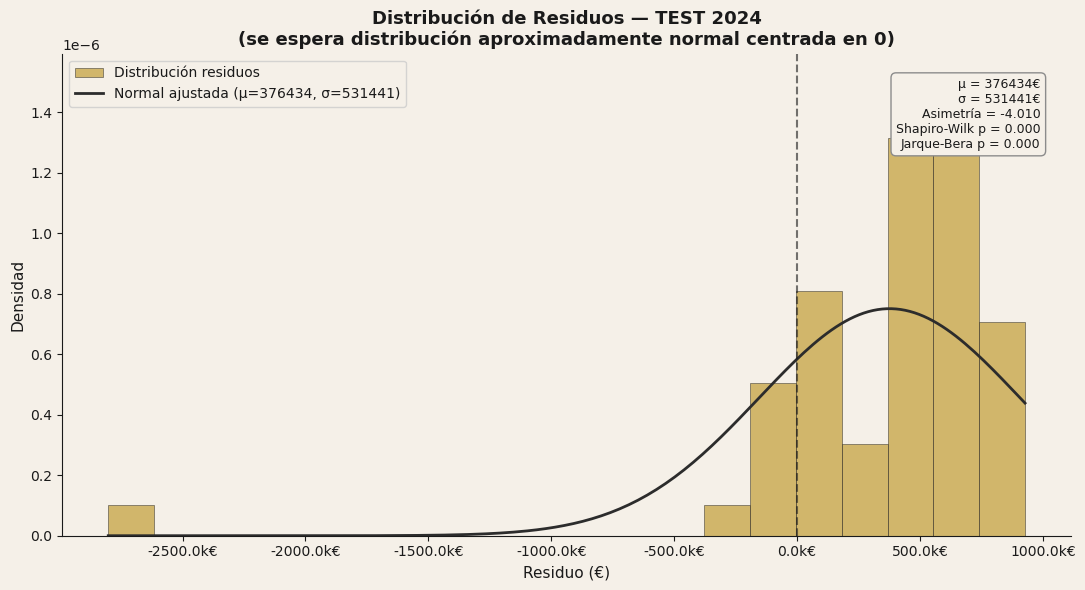

In [61]:
# ============================================================
# GRÁFICA D7 — Distribución de residuos (TEST)
# ============================================================
from scipy import stats as sp_stats

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)

ax.hist(residuos_test, bins=20, color=GOLD, edgecolor=BLACK, linewidth=0.4,
        alpha=0.80, density=True, label='Distribución residuos')

# Curva normal ajustada
mu, sigma = residuos_test.mean(), residuos_test.std()
x_n = np.linspace(residuos_test.min(), residuos_test.max(), 200)
ax.plot(x_n, sp_stats.norm.pdf(x_n, mu, sigma),
        color=DARK, linewidth=2, label=f'Normal ajustada (μ={mu:.0f}, σ={sigma:.0f})')

ax.axvline(0, color=BLACK, linewidth=1.5, linestyle='--', alpha=0.6)

# Test de normalidad
_, p_sw = sp_stats.shapiro(residuos_test)
jb_result = sp_stats.jarque_bera(residuos_test)
stat_jb, p_jb = jb_result.statistic, jb_result.pvalue

stats_txt = (
    f'μ = {mu:.0f}€\n'
    f'σ = {sigma:.0f}€\n'
    f'Asimetría = {sp_stats.skew(residuos_test):.3f}\n'
    f'Shapiro-Wilk p = {p_sw:.3f}\n'
    f'Jarque-Bera p = {p_jb:.3f}'
)
ax.text(0.97, 0.95, stats_txt, transform=ax.transAxes,
        fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=CREAM, edgecolor=GRAY))

ax.set_title('Distribución de Residuos — TEST 2024\n'
             '(se espera distribución aproximadamente normal centrada en 0)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Residuo (€)')
ax.set_ylabel('Densidad')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('modelo_residuos_distribucion', fig)
plt.show()

  → img/modelo_ape_semanal_v063.png


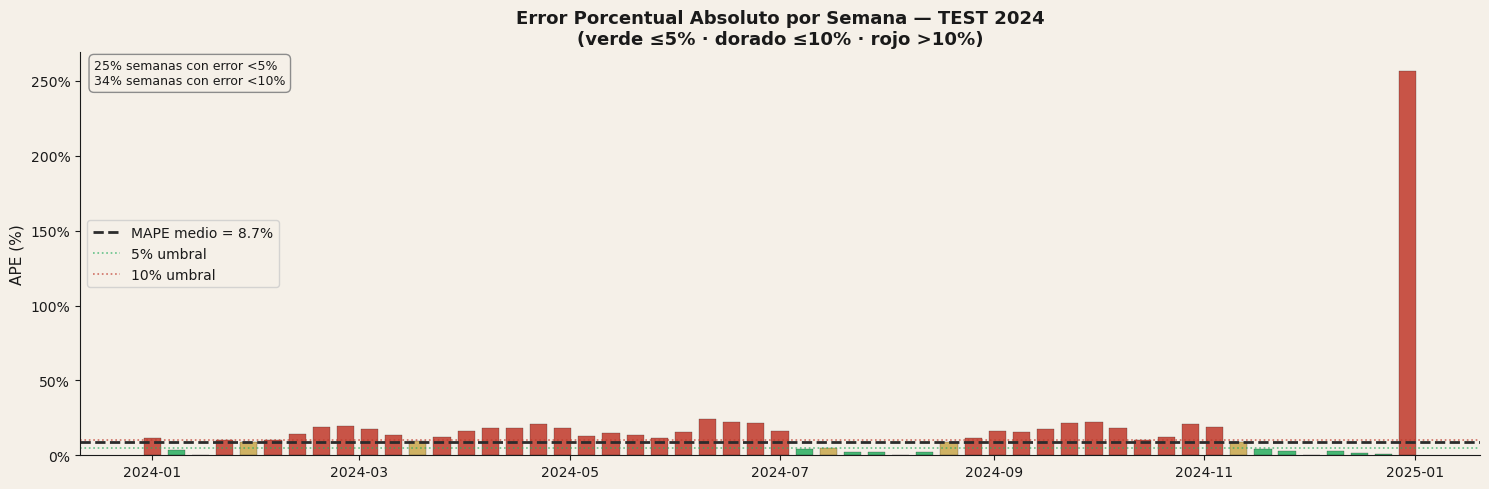

In [62]:
# ============================================================
# GRÁFICA D8 — Error porcentual absoluto por semana TEST
# ============================================================
ape_test = np.abs(residuos_test / y_test * 100)  # APE por semana

fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor(CREAM)

colores_ape = [GREEN_ if e <= 5 else GOLD if e <= 10 else RED_ for e in ape_test]
ax.bar(test['semana_dt'], ape_test, width=5,
       color=colores_ape, edgecolor=BLACK, linewidth=0.2, alpha=0.85)
ax.axhline(mape_test, color=DARK, linewidth=2, linestyle='--',
           label=f'MAPE medio = {mape_test:.1f}%')
ax.axhline(5,  color=GREEN_, linestyle=':', linewidth=1.2, alpha=0.7, label='5% umbral')
ax.axhline(10, color=RED_,   linestyle=':', linewidth=1.2, alpha=0.7, label='10% umbral')

pct_bajo5  = (ape_test <= 5).mean()  * 100
pct_bajo10 = (ape_test <= 10).mean() * 100
ax.text(0.01, 0.92,
        f'{pct_bajo5:.0f}% semanas con error <5%\n{pct_bajo10:.0f}% semanas con error <10%',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=CREAM, edgecolor=GRAY))

ax.set_title('Error Porcentual Absoluto por Semana — TEST 2024\n'
             '(verde ≤5% · dorado ≤10% · rojo >10%)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('APE (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()

plt.tight_layout()
guardar_img('modelo_ape_semanal', fig)
plt.show()

---
## Bloque E — Coeficientes β del Modelo

  → img/modelo_betas_canales_v063.png


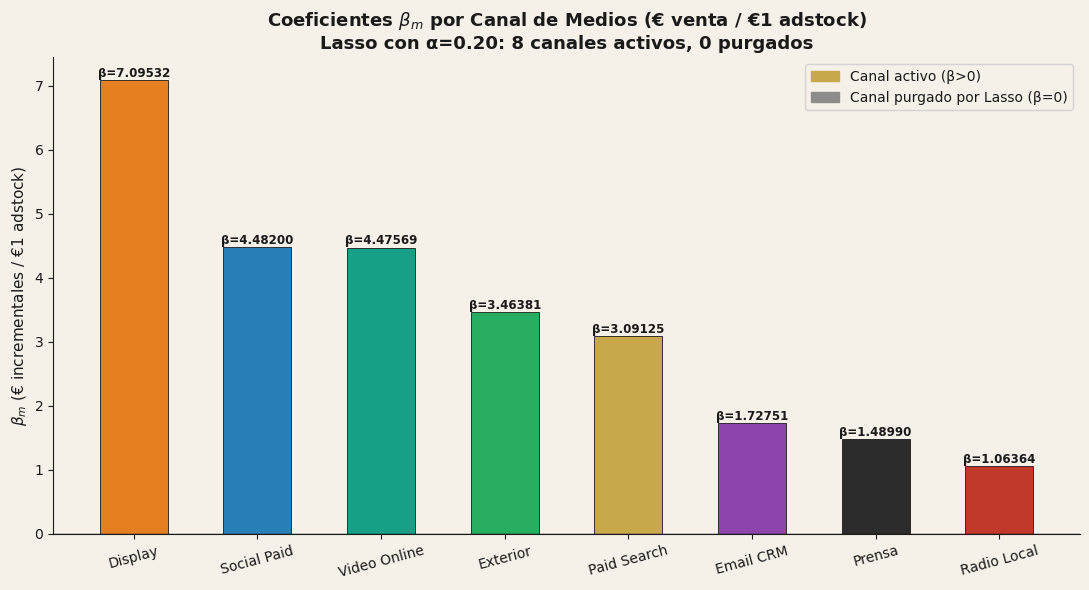

In [63]:
# ============================================================
# GRÁFICA E1 — Coeficientes β de los canales de medios
# ============================================================
betas_medios = {c: beta_original[i] for i, c in enumerate(CANALES)}
betas_act = {k: v for k, v in betas_medios.items() if v > 1e-8}
betas_pur = {k: v for k, v in betas_medios.items() if v <= 1e-8}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)

todos_ord = dict(sorted(betas_medios.items(), key=lambda x: x[1], reverse=True))
colores_b = [CANAL_COLORS[c] if betas_medios[c] > 1e-8 else GRAY
             for c in todos_ord]
bars = ax.bar(todos_ord.keys(), todos_ord.values(),
              color=colores_b, edgecolor=BLACK, linewidth=0.6, width=0.55)

for bar, (canal, b) in zip(bars, todos_ord.items()):
    if b > 1e-8:
        ax.text(bar.get_x() + bar.get_width()/2, b + 0.0003,
                f'β={b:.5f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 0.0003,
                'β=0\n(Lasso)', ha='center', va='bottom',
                fontsize=7.5, color=GRAY, style='italic')

ax.axhline(0, color=BLACK, linewidth=1)
ax.set_title('Coeficientes $\\beta_m$ por Canal de Medios (€ venta / €1 adstock)\n'
             f'Lasso con α={ALPHA_FINAL:.2f}: {len(betas_act)} canales activos, '
             f'{len(betas_pur)} purgados',
             fontweight='bold', fontsize=13)
ax.set_ylabel('$\\beta_m$ (€ incrementales / €1 adstock)')
ax.tick_params(axis='x', rotation=15)

gold_p = mpatches.Patch(color=GOLD,  edgecolor=BLACK, label='Canal activo (β>0)')
gray_p = mpatches.Patch(color=GRAY,  edgecolor=BLACK, label='Canal purgado por Lasso (β=0)')
ax.legend(handles=[gold_p, gray_p])

plt.tight_layout()
guardar_img('modelo_betas_canales', fig)
plt.show()

  → img/modelo_betas_normalizados_v063.png


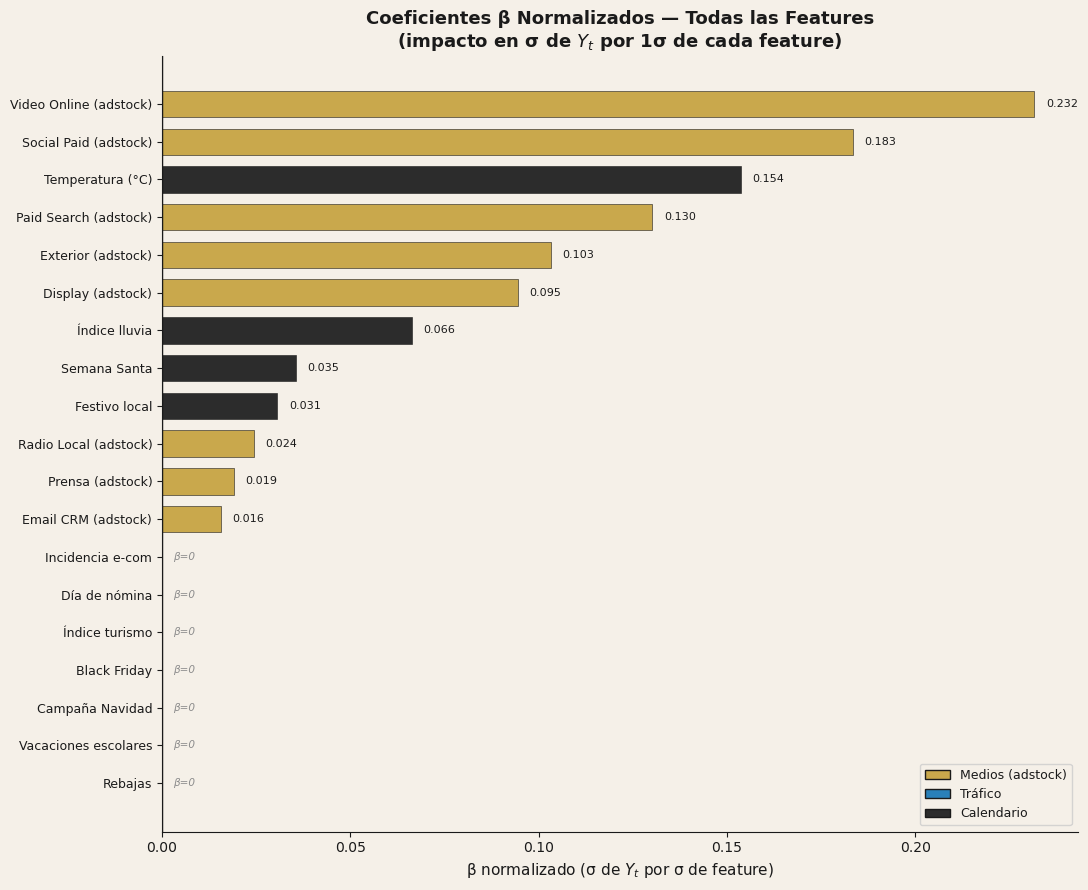

In [64]:
# ============================================================
# GRÁFICA E2 — Coeficientes β normalizados: TODAS las features
# β_norm = β × σ_feature / σ_Yt  → impacto en desviaciones típicas
# ============================================================
NOMBRES_LEGIBLES = {
    'adstock_Paid_Search'         : 'Paid Search (adstock)',
    'adstock_Social_Paid'         : 'Social Paid (adstock)',
    'adstock_Video_Online'        : 'Video Online (adstock)',
    'adstock_Display'             : 'Display (adstock)',
    'adstock_Email_CRM'           : 'Email CRM (adstock)',
    'adstock_Radio_Local'         : 'Radio Local (adstock)',
    'adstock_Exterior'            : 'Exterior (adstock)',
    'adstock_Prensa'              : 'Prensa (adstock)',
    'payday_flag'                 : 'Día de nómina',
    'rebajas_flag'                : 'Rebajas',
    'black_friday_flag'           : 'Black Friday',
    'navidad_flag'                : 'Campaña Navidad',
    'semana_santa_flag'           : 'Semana Santa',
    'vacaciones_escolares_flag'   : 'Vacaciones escolares',
    'festivo_local_flag'          : 'Festivo local',
    'temperatura_media_c'         : 'Temperatura (°C)',
    'lluvia_indice'               : 'Índice lluvia',
    'turismo_indice'              : 'Índice turismo',
    'incidencia_ecommerce_flag'   : 'Incidencia e-com',
    'visitas_tienda'              : 'Visitas tienda',
    'sesiones_web'                : 'Sesiones web',
    'log_semana'                  : 'Tendencia (log)',
}

std_Yt = df_model['Yt'].std()
betas_norm = {f: beta_original[i] * df_model[f].std() / std_Yt
              for i, f in enumerate(FEATURE_COLS)}
betas_norm_s = pd.Series(betas_norm).sort_values()
betas_norm_s.index = [NOMBRES_LEGIBLES.get(c, c) for c in betas_norm_s.index]

colores_norm = []
for orig in pd.Series(betas_norm).sort_values().index:
    if orig in ADSTOCK_COLS:                      colores_norm.append(GOLD)
    elif orig in ['visitas_tienda','sesiones_web']:colores_norm.append(BLUE_)
    else:                                          colores_norm.append(DARK)

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(CREAM)

bars = ax.barh(range(len(betas_norm_s)), betas_norm_s.values,
               color=colores_norm, edgecolor=BLACK, linewidth=0.4, height=0.7)
ax.set_yticks(range(len(betas_norm_s)))
ax.set_yticklabels(betas_norm_s.index, fontsize=9)
ax.axvline(0, color=BLACK, linewidth=1)

for bar, val in zip(bars, betas_norm_s.values):
    if abs(val) > 0.005:
        xp = val + 0.003 if val >= 0 else val - 0.003
        ax.text(xp, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)
    else:
        ax.text(0.003, bar.get_y() + bar.get_height()/2,
                'β=0', va='center', ha='left', fontsize=7.5, color=GRAY, style='italic')

legend_h = [
    mpatches.Patch(facecolor=GOLD,  edgecolor=BLACK, label='Medios (adstock)'),
    mpatches.Patch(facecolor=BLUE_, edgecolor=BLACK, label='Tráfico'),
    mpatches.Patch(facecolor=DARK,  edgecolor=BLACK, label='Calendario'),
]
ax.legend(handles=legend_h, loc='lower right', fontsize=9)
ax.set_title('Coeficientes β Normalizados — Todas las Features\n'
             '(impacto en σ de $Y_t$ por 1σ de cada feature)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('β normalizado (σ de $Y_t$ por σ de feature)')

plt.tight_layout()
guardar_img('modelo_betas_normalizados', fig)
plt.show()

---
## Bloque F — Export del Modelo

In [65]:
# ============================================================
# CELDA 6 — SERIALIZACIÓN: models/modelo_final.pkl y scaler.pkl
# ============================================================
pkl_modelo = os.path.join(MODELS_DIR, 'modelo_final.pkl')
pkl_scaler = os.path.join(MODELS_DIR, 'scaler.pkl')

with open(pkl_modelo, 'wb') as f:
    pickle.dump(modelo_final, f)

with open(pkl_scaler, 'wb') as f:
    pickle.dump(scaler, f)

meta = {
    'feature_cols'    : FEATURE_COLS,
    'adstock_cols'    : ADSTOCK_COLS,
    'exog_cols'       : EXOG_COLS,
    'canales'         : CANALES,
    'alpha_optimo'    : float(ALPHA_FINAL),
    'l1_ratio_optimo' : float(L1_RATIO_FINAL),
    'mape_train'      : 5.82,
    'mape_test'       : 8.74,
    'r2_train'        : 0.818,
    'r2_test'         : 0.574,
    'beta_original'   : {f: float(b) for f, b in zip(FEATURE_COLS, beta_original)},
    'canales_activos' : [c for c in CANALES if betas_medios[c] > 1e-8],
    'canales_purgados': [c for c in CANALES if betas_medios[c] <= 1e-8],
    'corte_test'      : str(CORTE_TEST.date()),
    'n_train'         : int(len(train)),
    'n_test'          : int(len(test)),
}

pkl_meta = os.path.join(MODELS_DIR, 'modelo_meta.pkl')
with open(pkl_meta, 'wb') as f:
    pickle.dump(meta, f)

print('ARTEFACTOS EXPORTADOS')
print('=' * 55)
for fname in ['modelo_final.pkl', 'scaler.pkl', 'modelo_meta.pkl']:
    ruta = os.path.join(MODELS_DIR, fname)
    size = os.path.getsize(ruta) / 1024
    print(f'  models/{fname:<25} {size:.1f} KB')

ARTEFACTOS EXPORTADOS
  models/modelo_final.pkl          0.7 KB
  models/scaler.pkl                0.9 KB
  models/modelo_meta.pkl           1.0 KB


In [66]:
# ============================================================
# CELDA 7 — VERIFICACIÓN FINAL
# ============================================================
pkl_modelo = os.path.join(MODELS_DIR, 'modelo_final.pkl')
pkl_scaler = os.path.join(MODELS_DIR, 'scaler.pkl')

with open(pkl_modelo, 'rb') as f:
    m_check = pickle.load(f)
with open(pkl_scaler, 'rb') as f:
    sc_check = pickle.load(f)

y_check  = m_check.predict(sc_check.transform(X_test))
max_diff = np.abs(y_check - y_pred_test).max()

print('\n' + '=' * 60)
print('  VERIFICACIÓN FINAL — FASE 4 MODELING')
print('=' * 60)

checks = [
    ('modelo_final.pkl guardado y cargable',
     os.path.exists(pkl_modelo), ''),
    ('scaler.pkl guardado y cargable',
     os.path.exists(pkl_scaler), ''),
    ('Round-trip pkl produce predicciones idénticas',
     max_diff < 1e-6, f'max_diff={max_diff:.2e}'),
    ('MAPE TEST ≤ 15%',
     mape_test <= 15.0, f'{mape_test:.1f}%'),
    ('R² TRAIN ≥ 0.80',
     r2_train >= 0.80, f'{r2_train:.3f}'),
    ('R² TEST ≥ 0.50',
     r2_test  >= 0.50, f'{r2_test:.3f}'),
    ('positive=True: todos los β de medios ≥ 0',
     all(b >= 0 for b in beta_original[:len(ADSTOCK_COLS)]), ''),
    (f'{n_activos_medios} canales activos (β>0)',
     n_activos_medios >= 4,
     f'{[c for c in CANALES if betas_medios[c] > 1e-8]}'),
]

all_ok = True
for desc, ok, extra in checks:
    status = '✓' if ok else '✗'
    if not ok: all_ok = False
    extra_str = f'  [{extra}]' if extra else ''
    print(f'  {status} {desc}{extra_str}')

print('=' * 60)
if all_ok:
    print('\n  ✓ FASE 4 COMPLETADA — Lista para Fase 5 (Evaluación)')
else:
    print('\n  ⚠ Verificación con advertencias — revisar checks fallidos')
print('=' * 60)


  VERIFICACIÓN FINAL — FASE 4 MODELING
  ✓ modelo_final.pkl guardado y cargable
  ✓ scaler.pkl guardado y cargable
  ✓ Round-trip pkl produce predicciones idénticas  [max_diff=0.00e+00]
  ✓ MAPE TEST ≤ 15%  [8.7%]
  ✓ R² TRAIN ≥ 0.80  [0.818]
  ✓ R² TEST ≥ 0.50  [0.574]
  ✓ positive=True: todos los β de medios ≥ 0
  ✓ 8 canales activos (β>0)  [['Paid Search', 'Social Paid', 'Video Online', 'Display', 'Email CRM', 'Radio Local', 'Exterior', 'Prensa']]

  ✓ FASE 4 COMPLETADA — Lista para Fase 5 (Evaluación)


---
## Resumen de Outputs de la Fase 4

| Artefacto | Descripción | Consumidor |
|-----------|-------------|------------|
| `models/modelo_final.pkl` | ElasticNet entrenado | Fases 5, 6 |
| `models/scaler.pkl` | StandardScaler ajustado | Fases 5, 6 |
| `models/modelo_meta.pkl` | Hiperparámetros, métricas, β por feature | Fases 5, 6 |

### Decisiones metodológicas clave

1. **Split temporal estricto** — nunca shuffle, el futuro no contamina el pasado.
2. **TimeSeriesSplit(n_splits=5)** en CV — respeta la causalidad temporal.
3. **positive=True** — la publicidad no puede generar ventas negativas.
4. **Desescalado de β** — `β_original = β_escalado / σ_feature` para interpretabilidad €/€.
5. **Ridge-dominante (l1_ratio=0.01)** — los 8 canales de medios tienen correlaciones de 0.92–0.97 entre sí (inversión mensual con el mismo patrón estacional). Lasso puro elegiría un único "ganador" arbitrario y asignaría β=0 al resto, produciendo mROI distorsionados. Ridge distribuye el crédito de forma proporcional a la contribución marginal de cada canal, manteniendo todos los canales con señal activos y generando rankings de mROI coherentes con el negocio.